In [360]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
import miceforest as mf

## 1) Scraping GICS from Wikipedia:

Scraping from wikipedia the GICS Sector info and saving it to an excel file:

In [361]:
# url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# response = requests.get(url)
# soup = BeautifulSoup(response.text, 'html.parser')
# table = soup.find('tbody')
# data = []
# rows = table.find_all('tr')
# for row in rows:
#   cells = row.find_all('td')
#   row_data = [cell.get_text(strip=True) for cell in cells]
#   data.append(row_data)

# symbol_wiki = pd.DataFrame(data)
# columns = ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date Added', 'CIK', 'Founded']
# symbol_wiki.columns = columns
# symbol_wiki = symbol_wiki.iloc[1:]
# #print(symbol_wiki.head())
#symbol_wiki.to_excel("Data/symbol_wiki.xlsx", index = False)

Load the excel file with the GICS Sector information associated to the Symbol:

In [362]:
symbol_wiki = pd.read_excel("Data/symbol_wiki.xlsx")

In [363]:
symbol_wiki.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date Added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


Read the dataset with the symbol for each company of the S&P 500 (composition of december 2022) from LSEG Workspace, to match it with GICS data from wikipedia:

In [364]:
type_lseg = pd.read_excel("Data/symbol_comp_1222.xlsm", sheet_name="SYMBOL", dtype=str).iloc[0].values[1:]
symbol_lseg = pd.read_excel("Data/symbol_comp_1222.xlsm", sheet_name="SYMBOL", dtype=str, header=2)
symbol_lseg = symbol_lseg.iloc[:1].transpose().reset_index().rename(columns= {"index": "NAME", 0: "SYMBOL"}).iloc[1:]
symbol_lseg['TYPE'] = type_lseg
gics = pd.merge(symbol_lseg, symbol_wiki[['Symbol', 'GICS Sector']], how = 'left', left_on = 'SYMBOL', right_on='Symbol')

In [365]:
gics.head()

,NAME,SYMBOL,TYPE,Symbol,GICS Sector
0,AMAZON.COM,AMZN,891399,AMZN,Consumer Discretionary
1,ABBOTT LABORATORIES,ABT,916328,ABT,Health Care
2,AES,AES,545101,AES,Utilities
3,INTERNATIONAL BUS.MCHS.,IBM,906187,IBM,Information Technology
4,ADVANCED MICRO DEVICES,AMD,936365,AMD,Information Technology


## 2) Fill the missing GICS values manually from online sources:

In [366]:
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ROBERT HALF"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ALASKA AIR GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "AMERICAN AIRLINES GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BIO-RAD LABORATORIES 'A'"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "TELEFLEX"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ILLUMINA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CATALENT DEAD - DELIST.18/12/24"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DENTSPLY SIRONA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ORGANON"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ETSY"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BORGWARNER"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "V F"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WHIRLPOOL"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BATH AND BODY WORKS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ADV.AUTO PARTS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WESTROCK DEAD - DELIST.08/07/24"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CELANESE"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FMC"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SEALED AIR"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PIONEER NTRL.RES. DEAD - DELIST.03/05/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "MARATHON OIL DEAD - DELIST.22/11/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ZIONS BANCORP."), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "COMERICA"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISCOVER FINANCIAL SVS. DEAD - DELIST.19/05/25"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LINCOLN NATIONAL"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SVB FINANCIAL GROUP DEAD - DELIST.08/11/24"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SIGNATURE BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FIRST REPUBLIC BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "QORVO"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SOLAREDGE TECHNOLOGIES"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DXC TECHNOLOGY"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISH NETWORK 'A' DEAD - DELIST.02/01/24"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ACTIVISION BLIZZARD DEAD - DELIST.16/10/23"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LUMEN TECHNOLOGIES"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "NEWELL BRANDS (XSC)"), 'GICS Sector'] = 'Consumer Staples'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "VORNADO REALTY TRUST"), 'GICS Sector'] = 'Real Estate'

In [367]:
gics.loc[gics['SYMBOL'].isin(['CEG', 'OGN']), ['SYMBOL', 'GICS Sector']]

,SYMBOL,GICS Sector
454,OGN,Health Care
460,CEG,Utilities


In [276]:
gics.loc[(gics['GICS Sector'].isna())]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector


In [277]:
gics.groupby(['GICS Sector'])['NAME'].count()

GICS Sector
Communication Services    25
Consumer Discretionary    52
Consumer Staples          37
Energy                    23
Financials                75
Health Care               63
Industrials               74
Information Technology    63
Materials                 29
Real Estate               32
Utilities                 30
Name: NAME, dtype: int64

Change the Symbol of BERKSHIRE HATHAWAY 'B' from BRK.A to BRK-B as it is the correct symbol:

In [278]:
gics.loc[(gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'SYMBOL'] = 'BRK-B' 

## 3) Calculate the weights within sector, using adjusted close price for corporate splits and Free Float Number of Shares Outstanding

the weights are calculated as of the last market trading day of 2022.

Taking the last day of 2022 closing prices adjusted for corporate splits (from LSEG):

In [279]:
price = pd.read_excel("Data/price_div_comp_1222.xlsm", sheet_name="CLOSE PRICE", header=3)
price = price.iloc[1:]
price = price.transpose()
price.columns = price.iloc[0]
price = price.iloc[1:]
price = price['2022-12-29']
price.name = "Price last day dic 22"

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


In [280]:
price.head()

AMAZON.COM                  84.18
ABBOTT LABORATORIES        110.31
AES                         28.81
INTERNATIONAL BUS.MCHS.    141.06
ADVANCED MICRO DEVICES      64.82
Name: Price last day dic 22, dtype: object

Taking the last day of 2022 free float number of shares outstanding adjusted for corporate splits (from LSEG):

In [281]:
ffnosh = pd.read_excel("Data/price_div_comp_1222.xlsm", sheet_name="FFNOSH", header=3)
ffnosh = ffnosh.iloc[1:]
ffnosh = ffnosh.transpose()
ffnosh.columns = ffnosh.iloc[0]
ffnosh = ffnosh.iloc[1:]
ffnosh = ffnosh['2022-12-29']
ffnosh.name = "ffnosh last day dic 22"

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


In [282]:
ffnosh.index = ffnosh.index.str.replace(' - DS FREE FLOAT SHRE', '', regex=False)

In [283]:
ffnosh.head()

AMAZON.COM                 9249366
ABBOTT LABORATORIES        1654707
AES                         502652
INTERNATIONAL BUS.MCHS.     853138
ADVANCED MICRO DEVICES     1207610
Name: ffnosh last day dic 22, dtype: object

In [284]:
ffnosh = pd.DataFrame(ffnosh)
price = pd.DataFrame(price)

In [285]:
gics = pd.merge(gics, ffnosh, how = 'left', left_on = 'NAME', right_index=True)

In [286]:
gics = pd.merge(gics, price, how = 'left', left_on = 'NAME', right_index=True)

Checking for nans:

In [287]:
gics.loc[gics['Price last day dic 22'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day dic 22,Price last day dic 22


In [288]:
gics.loc[gics['ffnosh last day dic 22'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day dic 22,Price last day dic 22


In [289]:
gics = gics.loc[: , ['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day dic 22', 'Price last day dic 22']]

Calculating weights within sector:

In [290]:
# STEP 1: Group by SYMBOL to combine share classes -> in this way duplicates such as NWSA, FOXA, GOOGL are counted as one weight (bc their emissions are reported at the parent company level)
aggregated = gics.groupby('SYMBOL').apply(
    lambda df: pd.Series({
        'TYPE': df['TYPE'].iloc[0],
        'Company Name': df['NAME'].iloc[0],
        'GICS Sector': df['GICS Sector'].iloc[0],
        'Total ffnosh': df['ffnosh last day dic 22'].sum(),
        'Weighted Price': (df['ffnosh last day dic 22'] * df['Price last day dic 22']).sum() / df['ffnosh last day dic 22'].sum()
    })
).reset_index()

# STEP 2: Calculate float-adjusted market cap
aggregated['float_mcap'] = aggregated['Total ffnosh'] * aggregated['Weighted Price']

# STEP 3: Compute sector totals
sector_total = aggregated.groupby('GICS Sector')['float_mcap'].transform('sum')

# STEP 4: Compute weight within sector
aggregated['weight_in_sector'] = aggregated['float_mcap'] / sector_total

# Optional: sort by sector or weight
aggregated = aggregated.sort_values(by=['GICS Sector', 'weight_in_sector'], ascending=[True, False])

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/2488156636.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = gics.groupby('SYMBOL').apply(


NB:

Free float = the number of shares available for trading in the market.

Excludes shares held by:

Founders

Governments

Strategic long-term investors (who won’t sell in the market)

In [291]:
gics[gics['SYMBOL'].duplicated(keep=False)]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day dic 22,Price last day dic 22
412,NEWS 'A',89257H,NWSA,Communication Services,291946,18.22
413,NEWS 'B',89257J,NWSA,Communication Services,97439,18.46
436,FOX A,9406MC,FOXA,Communication Services,280245,30.56
437,FOX B,9406MA,FOXA,Communication Services,144424,28.58
490,ALPHABET 'A',29026M,GOOGL,Communication Services,5964000,88.45
497,ALPHABET 'C',871997,GOOGL,Communication Services,5611228,88.95


In [292]:
aggregated

,SYMBOL,TYPE,Company Name,GICS Sector,Total ffnosh,Weighted Price,float_mcap,weight_in_sector
206,GOOGL,29026M,ALPHABET 'A',Communication Services,11575228,88.692381,1.026635e+09,0.439655
299,META,86831C,META PLATFORMS A,Communication Services,2242027,120.260000,2.696262e+08,0.115467
97,CMCSA,981550,COMCAST A,Communication Services,4559479,35.050000,1.598097e+08,0.068438
136,DIS,921964,WALT DISNEY,Communication Services,1817656,87.180000,1.584633e+08,0.067862
472,VZ,945384,VERIZON COMMUNICATIONS,Communication Services,3917961,39.260000,1.538191e+08,0.065873
...,...,...,...,...,...,...,...,...
43,ATO,511339,ATMOS ENERGY,Utilities,115149,114.490000,1.318341e+07,0.013867
279,LNT,906979,ALLIANT ENERGY (XSC),Utilities,233071,56.030000,1.305897e+07,0.013736
330,NI,906176,NISOURCE,Utilities,375391,27.840000,1.045089e+07,0.010993
372,PNW,902607,PINNACLE WEST CAP.,Utilities,104645,77.130000,8.071269e+06,0.008490


In [294]:
pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE').loc[pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE')['SYMBOL']=='GOOGL']

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day dic 22,Price last day dic 22,weight_in_sector,float_mcap
490,ALPHABET 'A',29026M,GOOGL,Communication Services,5964000,88.45,0.439655,1.026635e+09
497,ALPHABET 'C',871997,GOOGL,Communication Services,5611228,88.95,NaN,NaN


After grouping by SYMBOL, each company has one weight_in_sector. When merging back, only one of the share classes (TYPE) keeps the weight, the other appears as NaN. This avoids double-counting and I can therefore merge on Type:

In [295]:
gics = pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE') 

In [296]:
gics.loc[gics['GICS Sector'] == 'Communication Services']['weight_in_sector'].sum()

1.0

In [297]:
len(gics)

503

In [298]:
gics.groupby(['GICS Sector'])['weight_in_sector'].sum()

GICS Sector
Communication Services    1.0
Consumer Discretionary    1.0
Consumer Staples          1.0
Energy                    1.0
Financials                1.0
Health Care               1.0
Industrials               1.0
Information Technology    1.0
Materials                 1.0
Real Estate               1.0
Utilities                 1.0
Name: weight_in_sector, dtype: float64

## 4) Read and merge scope emissions data

In [299]:
scope_emission_1  = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="SCOPE 1", header=4).iloc[107]
#print(scope_emission_1)
scope_emission_1.index = scope_emission_1.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_1 = pd.DataFrame(scope_emission_1)
scope_emission_1.columns = ['Scope 1']
scope_emission_1 = scope_emission_1.iloc[1:]
scope_emission_1.index.name = 'Type'

scope_emission_2  = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="SCOPE 2", header=4).iloc[107]
scope_emission_2.index = scope_emission_2.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_2 = pd.DataFrame(scope_emission_2)
scope_emission_2.columns = ['Scope 2']
scope_emission_2 = scope_emission_2.iloc[1:]
scope_emission_2.index.name = 'Type'

scope_emission_3  = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="SCOPE 3", header=4).iloc[107]
scope_emission_3.index = scope_emission_3.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_3 = pd.DataFrame(scope_emission_3)
scope_emission_3.columns = ['Scope 3']
scope_emission_3 = scope_emission_3.iloc[1:]
scope_emission_3.index.name = 'Type'

In [300]:
revenue = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="REVENUE", header=4).iloc[1:].iloc[107]
revenue.index = revenue.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
revenue = pd.DataFrame(revenue)
revenue.columns = ['Revenue']
revenue = revenue.iloc[1:]
revenue.index.name = 'Type'

In [301]:
gics = pd.merge(gics, scope_emission_1, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_2, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_3, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, revenue, how = 'left', left_on = 'TYPE', right_index=True)

In [304]:
gics.loc[gics['SYMBOL'].isin(['GOOGL', 'NWSA', 'FOXA'])]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day dic 22,Price last day dic 22,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue
412,NEWS 'A',89257H,NWSA,Communication Services,291946,18.22,0.003048,7.117980e+06,12700.0,64000.0,866960.0,9879000.0
413,NEWS 'B',89257J,NWSA,Communication Services,97439,18.46,NaN,NaN,12700.0,64000.0,866960.0,9879000.0
436,FOX A,9406MC,FOXA,Communication Services,280245,30.56,0.005435,1.269193e+07,14266.0,52944.0,11877.0,14913000.0
437,FOX B,9406MA,FOXA,Communication Services,144424,28.58,NaN,NaN,14266.0,52944.0,11877.0,14913000.0
490,ALPHABET 'A',29026M,GOOGL,Communication Services,5964000,88.45,0.439655,1.026635e+09,91200.0,8045400.0,10034000.0,307394000
497,ALPHABET 'C',871997,GOOGL,Communication Services,5611228,88.95,NaN,NaN,91200.0,8045400.0,10034000.0,307394000


So since the Scope emissions and Revenue are reported at parent company level I can now remove the duplicates by keeping the first row:

In [305]:
gics = gics[~gics['SYMBOL'].duplicated(keep='first')]

In [306]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']

In [307]:
missing_scopes_type = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'TYPE'].values)

In [308]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'SYMBOL'].values)

In [309]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'NAME'].values)

In [310]:
len(set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values))))

30

In [311]:
scope_1_2_nan = set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values)))

In [312]:
len(scope_1_2_nan)

30

In [313]:
scope_1_2_3_nan = scope_1_2_nan.union(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

In [314]:
len(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

133

In [315]:
len(scope_1_2_3_nan)

135

In [316]:
len(missing_scopes)

27

In [317]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.227273
Consumer Discretionary    0.307692
Consumer Staples          0.216216
Energy                    0.434783
Financials                0.240000
Health Care               0.396825
Industrials               0.324324
Information Technology    0.190476
Materials                 0.137931
Real Estate               0.281250
Utilities                 0.133333
Name: count, dtype: float64

In [318]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     5
Consumer Discretionary    16
Consumer Staples           8
Energy                    10
Financials                18
Health Care               25
Industrials               24
Information Technology    12
Materials                  4
Real Estate                9
Utilities                  4
Name: count, dtype: int64

In [319]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.227273
Consumer Discretionary    0.307692
Consumer Staples          0.216216
Energy                    0.434783
Financials                0.240000
Health Care               0.396825
Industrials               0.324324
Information Technology    0.190476
Materials                 0.137931
Real Estate               0.281250
Utilities                 0.133333
Name: count, dtype: float64

In [320]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()[['Consumer Discretionary', 'Consumer Staples', 'Energy', 'Industrials', 'Information Technology', 'Materials', 'Utilities']].sum()

78

In [321]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     5
Consumer Discretionary    16
Consumer Staples           8
Energy                    10
Financials                18
Health Care               25
Industrials               24
Information Technology    12
Materials                  4
Real Estate                9
Utilities                  4
Name: count, dtype: int64

In [322]:
# gics.loc[gics['Carbon Intensity'].isna()]

SCOPE 3 IMPUTATION

In [323]:
gics.columns

Index(['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day dic 22',
       'Price last day dic 22', 'weight_in_sector', 'float_mcap', 'Scope 1',
       'Scope 2', 'Scope 3', 'Revenue', 'Scope 1+2+3', 'Carbon Intensity'],
      dtype='object')

In [324]:
# Filter the DataFrame to Financials sector
financials = gics[(gics['GICS Sector'] == 'Financials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
financials['% Scope 3'] = financials['Scope 3'] / financials['Scope 1+2+3'] * 100
#print(financials['% Scope 1'].mean())
#print(financials['% Scope 2'].mean())
#print(financials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/3156623907.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/3156623907.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/3156623907.py:7: SettingWit

In [325]:
# Filter the DataFrame to Industrials sector
industrials = gics[(gics['GICS Sector'] == 'Industrials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 3'] = industrials['Scope 3'] / industrials['Scope 1+2+3'] * 100
#print(industrials['% Scope 1'].mean())
#print(industrials['% Scope 2'].mean())
#print(industrials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/319877813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/319877813.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/319877813.py:7: Setting

- 20 manually (scraped from sust. reports) imputed scope 1 emissions (for 2 cases, I had the total scope 1+2+3)
- 19 manually (scraped from sust. reports) imputed scope 2 emissions (for 2 cases, I had the total scope 1+2+3)
- 16 manually (scraped from sust. reports) imputed scope 3 emissions (for 2 cases, I had the total scope 1+2+3)

In [326]:
anon_df = pd.read_csv("Data/anon_map.csv")
anon_map = dict(zip(anon_df['NAME'], anon_df['AnonID']))
gics['AnonID'] = gics['NAME'].map(anon_map)


In [327]:
# Load the file
data_patch = pd.read_csv("Data/scope_emissions_patch.csv", index_col=0)

# Remove NaN values and convert to nested dictionary
data_patch = {
    company: {col: val for col, val in row.items() if pd.notna(val)}
    for company, row in data_patch.iterrows()
}

In [328]:
# Apply using AnonID instead of NAME
for name, scopes in data_patch.items():
    anon_id = anon_map[name] #random_seed 42
    for scope, value in scopes.items():
        gics.loc[gics['AnonID'] == anon_id, scope] = value
        gics.loc[gics['AnonID'] == anon_id, f'Manually Imputed {scope}'] = 1

We still have:
- 11 cases where scope 1 & 2 & 3 are all nans
- 1 where only scope 2 and scope 3 is na
- 108 cases where only scope 3 is nan

In [329]:
import itertools

# Define the columns
scope_cols = ['Scope 1', 'Scope 2', 'Scope 3']

# Generate all combinations of True (NaN) and False (not NaN)
combinations = list(itertools.product([True, False], repeat=3))

# Loop through each combination and filter the DataFrame
for comb in combinations:
    condition = (
        (gics['Scope 1'].isna() if comb[0] else gics['Scope 1'].notna()) &
        (gics['Scope 2'].isna() if comb[1] else gics['Scope 2'].notna()) &
        (gics['Scope 3'].isna() if comb[2] else gics['Scope 3'].notna())
    )
    
    filtered = gics.loc[condition]
    #print(f"Combination (Scope 1 NaN: {comb[0]}, Scope 2 NaN: {comb[1]}, Scope 3 NaN: {comb[2]})")
    #print(len(filtered))
    #print("-" * 80)


- 4 cases where Revenue was nan and found online:

In [330]:
gics.loc[gics['NAME'] == 'ACTIVISION BLIZZARD DEAD - DELIST.16/10/23', 'Revenue'] = 7530000000
gics.loc[gics['NAME'] == 'SVB FINANCIAL GROUP DEAD - DELIST.08/11/24', 'Revenue'] = 6200000000
gics.loc[gics['NAME'] == 'SIGNATURE BANK', 'Revenue'] = 2600000000
gics.loc[gics['NAME'] == 'FIRST REPUBLIC BANK', 'Revenue'] = 5700000000

In [331]:
gics.loc[gics['Revenue'].isna()]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day dic 22,Price last day dic 22,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue,Scope 1+2+3,Carbon Intensity,AnonID,Manually Imputed Scope 1,Manually Imputed Scope 1+2+3,Manually Imputed Scope 2,Manually Imputed Scope 3


In [156]:
# gics_original = gics.copy()
# gics = gics.loc[~gics.NAME.isin(scope_1_2_nan)]

In [332]:
# Create dummies separately
sector_dummies = pd.get_dummies(gics['GICS Sector'], prefix='Sector')

# Concatenate the original DataFrame with dummies
gics = pd.concat([gics, sector_dummies], axis=1)


In [333]:
len(gics)

500

In [334]:

# Ensure Scope 3 is numeric
scope3_obs = pd.to_numeric(gics["Scope 3"], errors="coerce").dropna()

skewness = skew(scope3_obs)

#print(f"Skewness: {skewness:.2f}")



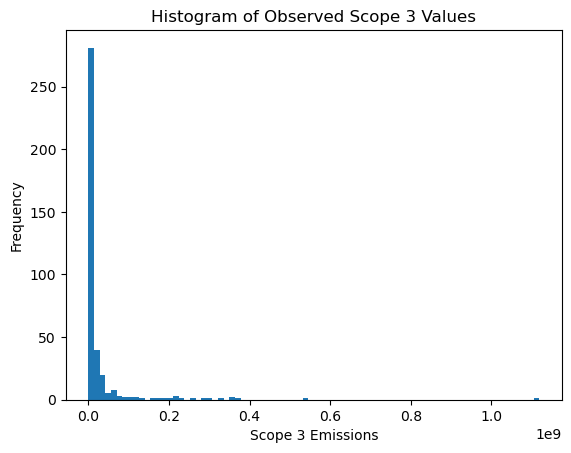

In [335]:

plt.hist(scope3_obs, bins=80)
plt.title("Histogram of Observed Scope 3 Values")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Frequency")
plt.show()


In [336]:
#print(f"Min: {scope3_obs.min()}, Max: {scope3_obs.max()}")


In [337]:
gics.loc[gics['NAME'] == 'DOLLAR GENERAL', ['Revenue', 'Scope 1', 'Scope 2', 'Scope 3']]

,Revenue,Scope 1,Scope 2,Scope 3
387,37844863,658617.0,1258232.0,NaN


In [338]:
gics.isna().any()

NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day dic 22           False
Price last day dic 22            False
weight_in_sector                 False
float_mcap                       False
Scope 1                           True
Scope 2                           True
Scope 3                           True
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                  True
AnonID                           False
Manually Imputed Scope 1          True
Manually Imputed Scope 1+2+3      True
Manually Imputed Scope 2          True
Manually Imputed Scope 3          True
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials       

In [339]:
gics.loc[gics['SYMBOL'].isin(['NWSA', 'FOXA', 'GOOGL']), ['NAME', 'ffnosh last day dic 22', 'float_mcap', 'Price last day dic 22', 'Scope 1', 'Scope 2', 'Scope 3', 'Revenue']]

,NAME,ffnosh last day dic 22,float_mcap,Price last day dic 22,Scope 1,Scope 2,Scope 3,Revenue
412,NEWS 'A',291946,7.117980e+06,18.22,12700.0,64000.0,866960.0,9879000.0
436,FOX A,280245,1.269193e+07,30.56,14266.0,52944.0,11877.0,14913000.0
490,ALPHABET 'A',5964000,1.026635e+09,88.45,91200.0,8045400.0,10034000.0,307394000


In [340]:
len(gics)

500

In [341]:
gics = gics[~gics['SYMBOL'].duplicated(keep='first')]

In [342]:
len(gics)

500

In [343]:
gics.loc[gics['SYMBOL'].isin(['NWSA', 'FOXA', 'GOOGL']), ['NAME', 'ffnosh last day dic 22', 'float_mcap', 'Price last day dic 22', 'Scope 1', 'Scope 2', 'Scope 3', 'Revenue']]

,NAME,ffnosh last day dic 22,float_mcap,Price last day dic 22,Scope 1,Scope 2,Scope 3,Revenue
412,NEWS 'A',291946,7.117980e+06,18.22,12700.0,64000.0,866960.0,9879000.0
436,FOX A,280245,1.269193e+07,30.56,14266.0,52944.0,11877.0,14913000.0
490,ALPHABET 'A',5964000,1.026635e+09,88.45,91200.0,8045400.0,10034000.0,307394000


In [344]:

columns = ["Scope 1", "Scope 2", "Revenue", "float_mcap", "Carbon Intensity", "Scope 3"]
sector_columns = [col for col in gics.columns if col.startswith("Sector_")]
all_cols = columns + sector_columns
# Convert all boolean columns to int (0/1)
bool_cols = gics.select_dtypes(include='bool').columns
gics[bool_cols] = gics[bool_cols].astype(int)

# Subset the data
data = gics[all_cols].copy().reset_index(drop=True)
# Show all columns with object dtype
# Step 1: Get all object columns
object_cols = data.select_dtypes(include="object").columns

# Step 2: Convert them to float
for col in object_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Initialize kernel (this builds multiple trees for imputation)
kernel = mf.ImputationKernel(
    data=data,
    num_datasets=3,
    mean_match_candidates=5,
    random_state=1
)

# Run MICE with PMM
kernel.mice(5)  # 5 iterations

# Extract imputed dataset
completed_data = kernel.complete_data(dataset=0)
# Identify missing Scope 3 values before imputation
missing_mask_original = gics["Scope 3"].isna() 
# Replace back into original
gics.reset_index(drop=True, inplace=True)
missing_mask = gics["Scope 3"].isna() 
gics.loc[gics['Scope 1'].isna(), "Scope 1 Imputed"] = 1
gics.loc[gics['Scope 2'].isna(), "Scope 2 Imputed"] = 1
gics.loc[gics['Scope 3'].isna(), "Scope 3 Imputed"] = 1


In [345]:
completed_data.iloc[387]

Scope 1                          6.586170e+05
Scope 2                          1.258232e+06
Revenue                          3.784486e+07
float_mcap                       4.920940e+07
Carbon Intensity                 5.065018e-02
Scope 3                          4.257276e+06
Sector_Communication Services    0.000000e+00
Sector_Consumer Discretionary    0.000000e+00
Sector_Consumer Staples          1.000000e+00
Sector_Energy                    0.000000e+00
Sector_Financials                0.000000e+00
Sector_Health Care               0.000000e+00
Sector_Industrials               0.000000e+00
Sector_Information Technology    0.000000e+00
Sector_Materials                 0.000000e+00
Sector_Real Estate               0.000000e+00
Sector_Utilities                 0.000000e+00
Name: 387, dtype: float64

In [346]:
gics.loc[gics['NAME'] == 'DOLLAR GENERAL', ['Revenue', 'Scope 1', 'Scope 2', 'Scope 3']]

,Revenue,Scope 1,Scope 2,Scope 3
387,37844863,658617.0,1258232.0,NaN


In [347]:
gics['Scope 1'] = completed_data["Scope 1"]
gics['Scope 2'] = completed_data["Scope 2"]
gics["Scope 3"] = completed_data["Scope 3"]

In [348]:
completed_data.iloc[387]

Scope 1                          6.586170e+05
Scope 2                          1.258232e+06
Revenue                          3.784486e+07
float_mcap                       4.920940e+07
Carbon Intensity                 5.065018e-02
Scope 3                          4.257276e+06
Sector_Communication Services    0.000000e+00
Sector_Consumer Discretionary    0.000000e+00
Sector_Consumer Staples          1.000000e+00
Sector_Energy                    0.000000e+00
Sector_Financials                0.000000e+00
Sector_Health Care               0.000000e+00
Sector_Industrials               0.000000e+00
Sector_Information Technology    0.000000e+00
Sector_Materials                 0.000000e+00
Sector_Real Estate               0.000000e+00
Sector_Utilities                 0.000000e+00
Name: 387, dtype: float64

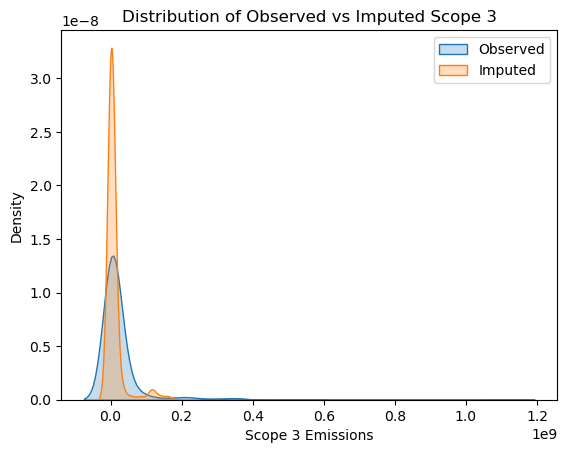

In [349]:
# Separate imputed and observed
imputed_values = gics.loc[missing_mask, "Scope 3"]
observed_values = gics.loc[~missing_mask, "Scope 3"]

# Plot
sns.kdeplot(observed_values, label="Observed", fill=True)
sns.kdeplot(imputed_values, label="Imputed", fill=True)
plt.title("Distribution of Observed vs Imputed Scope 3")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Density")
plt.legend()
plt.show()

- to do: calculate point to point deviation between observed scope 3 and predicted, could look at scatter plot by sector

In [350]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']
gics.isna().any()

NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day dic 22           False
Price last day dic 22            False
weight_in_sector                 False
float_mcap                       False
Scope 1                          False
Scope 2                          False
Scope 3                          False
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                 False
AnonID                           False
Manually Imputed Scope 1          True
Manually Imputed Scope 1+2+3      True
Manually Imputed Scope 2          True
Manually Imputed Scope 3          True
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials       

In [351]:
gics.loc[gics['GICS Sector'] == 'Communication Services']

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day dic 22,Price last day dic 22,weight_in_sector,float_mcap,Scope 1,Scope 2,...,Sector_Financials,Sector_Health Care,Sector_Industrials,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Utilities,Scope 1 Imputed,Scope 2 Imputed,Scope 3 Imputed
20,COMCAST A,981550,CMCSA,Communication Services,4559479,35.05,0.068438,1.598097e+08,496938.00,1480893.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
37,VERIZON COMMUNICATIONS,945384,VZ,Communication Services,3917961,39.26,0.065873,1.538191e+08,273904.00,3498643.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
48,TAKE TWO INTACT.SFTW.,889831,TTWO,Communication Services,107489,101.34,0.004665,1.089294e+07,1868.00,14892.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
96,WALT DISNEY,921964,DIS,Communication Services,1817656,87.18,0.067862,1.584633e+08,993347.00,782066.00,...,0,0,0,0,0,0,0,NaN,NaN,1.0
99,OMNICOM GROUP,932913,OMC,Communication Services,198223,81.59,0.006926,1.617301e+07,32915.00,34362.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
107,DISH NETWORK 'A' DEAD - DELIST.02/01/24,135448,DISH,Communication Services,251938,14.12,0.001523,3.557365e+06,40679.00,341699.00,...,0,0,0,0,0,0,0,1.0,1.0,1.0
110,ELECTRONIC ARTS,500320,EA,Communication Services,249506,122.19,0.013056,3.048714e+07,3875.00,19570.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
164,INTERPUBLIC GROUP,923465,IPG,Communication Services,339393,33.58,0.004881,1.139682e+07,11193.00,36553.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
201,ACTIVISION BLIZZARD DEAD - DELIST.16/10/23,312367,ATVI,Communication Services,729908,76.76,0.023994,5.602774e+07,2892.00,12309.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
288,AT&T,945388,T,Communication Services,7128000,18.45,0.056320,1.315116e+08,917036.00,4962516.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN


## 5) Recalculate weights in sector and market cap only for the sectors of CEG and OGN

In [352]:
gics_ceg_ogn_sectors_name = gics.loc[gics['SYMBOL'].isin(['CEG', 'OGN']), 'GICS Sector']
gics = gics.loc[~gics['SYMBOL'].isin(['CEG', 'OGN'])]

In [353]:
gics_ceg_ogn_sectors_name

452    Health Care
458      Utilities
Name: GICS Sector, dtype: object

In [176]:
# STEP 0: Assume `gics` is your original DataFrame
# Columns: SYMBOL, ffnosh, Price, GICS Sector

gics_ceg_ogn_sectors_filtered_df = gics.loc[gics['GICS Sector'].isin(gics_ceg_ogn_sectors_name.values)]
print(gics_ceg_ogn_sectors_filtered_df)
# STEP 1: Group by SYMBOL to combine share classes
aggregated = gics_ceg_ogn_sectors_filtered_df.groupby('SYMBOL').apply(
    lambda df: pd.Series({
        'TYPE': df['TYPE'].iloc[0],
        'Company Name': df['NAME'].iloc[0],
        'GICS Sector': df['GICS Sector'].iloc[0],
        'Total ffnosh': df['ffnosh last day dic 22'].sum(),
        'Weighted Price': (df['ffnosh last day dic 22'] * df['Price last day dic 22']).sum() / df['ffnosh last day dic 22'].sum()
    })
).reset_index()

# STEP 2: Calculate float-adjusted market cap
aggregated['float_mcap'] = aggregated['Total ffnosh'] * aggregated['Weighted Price']

# STEP 3: Compute sector totals
sector_total = aggregated.groupby('GICS Sector')['float_mcap'].transform('sum')

# STEP 4: Compute weight within sector
aggregated['weight_in_sector'] = aggregated['float_mcap'] / sector_total

# Optional: sort by sector or weight
aggregated = aggregated.sort_values(by=['GICS Sector', 'weight_in_sector'], ascending=[True, False])

                    NAME    TYPE SYMBOL  GICS Sector ffnosh last day dic 22  \
1    ABBOTT LABORATORIES  916328    ABT  Health Care                1654707   
2                    AES  545101    AES    Utilities                 502652   
12                 AMGEN  938692   AMGN  Health Care                 503343   
15        AMER.ELEC.PWR.  905425    AEP    Utilities                 483176   
26    PINNACLE WEST CAP.  902607    PNW    Utilities                 104645   
..                   ...     ...    ...          ...                    ...   
472      ELEVANCE HEALTH  14737P    ELV  Health Care                 226454   
474            MEDTRONIC  906496    MDT  Health Care                1271485   
478    EVERSOURCE ENERGY  921999     ES    Utilities                 324354   
482      DENTSPLY SIRONA  510209   XRAY  Health Care                 177433   
495     WEC ENERGY GROUP  902335    WEC    Utilities                 291410   

    Price last day dic 22  weight_in_sector    floa

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/4083169460.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = gics_ceg_ogn_sectors_filtered_df.groupby('SYMBOL').apply(


In [177]:
len(aggregated)

91

In [178]:
gics.loc[gics['GICS Sector'].isin(gics_ceg_ogn_sectors_name), ['weight_in_sector', 'float_mcap']] = np.nan

In [179]:
gics = pd.merge(gics, aggregated[['SYMBOL', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'SYMBOL', right_on = 'SYMBOL')

In [180]:
gics['weight_in_sector_x'] = gics['weight_in_sector_x'].fillna(gics['weight_in_sector_y'])
gics['float_mcap_x'] =  gics['float_mcap_x'].fillna(gics['float_mcap_y'])

In [181]:
gics['weight_in_sector'] = gics['weight_in_sector_x']
gics.drop(columns=['weight_in_sector_x', 'weight_in_sector_y'], inplace=True)

gics['float_mcap'] = gics['float_mcap_x']
gics.drop(columns=['float_mcap_x', 'float_mcap_y'], inplace=True)



In [182]:
len(gics)

498

In [183]:
gics.groupby(['GICS Sector'])['weight_in_sector'].sum()

GICS Sector
Communication Services    1.0
Consumer Discretionary    1.0
Consumer Staples          1.0
Energy                    1.0
Financials                1.0
Health Care               1.0
Industrials               1.0
Information Technology    1.0
Materials                 1.0
Real Estate               1.0
Utilities                 1.0
Name: weight_in_sector, dtype: float64

## 6) Fetch from Yahoo finance the adjusted price for corporate splits and dividends/capital gains (on LSEG is only adjusted for splits) -> to calculate covariance matrix

In [184]:
# # Define the tickers and date range
# tickers = list(gics['SYMBOL'].values) # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close[tickers[0]] = data['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close[ticker] = data[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close.head())



9 Failed downloads:
['SBNY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30) (Yahoo error = "Data doesn\'t exist for startDate = 1575176400, endDate = 1672376400")')
['DISH', 'CTLT', 'WRK', 'ATVI', 'MRO', 'SIVBQ', 'PXD']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30)')


In [185]:
# #print(gics.loc[gics['SYMBOL'] == 'BF.B'])
# # Define the tickers and date range
# tickers = ['BF-B'] # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data_bfb = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_bfb = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_bfb[tickers[0]] = data_bfb['BF-B']['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_bfb[ticker] = data_bfb[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close_bfb.head())
# adj_close['BF.B'] = adj_close_bfb.values

In [186]:
# adj_close.to_excel("Data/adj_prices_yahoo_comp_1222.xlsm")

In [187]:
adj_close = pd.read_excel("Data/adj_prices_yahoo_comp_1222.xlsm")
adj_close.index = adj_close.Date
adj_close.drop(columns='Date', inplace=True)

## 7) Fill in missing data from adjusted prices calculated manually or by refetching from Yahoo with the correct Symbol:

In [188]:
price = pd.read_excel('Data/price_div_comp_1222.xlsm', sheet_name='CLOSE PRICE', header = 4)
price.columns = price.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
#print(price.iloc[239:])
price = price.iloc[239:]

div_rate = pd.read_excel('Data/price_div_comp_1222.xlsm', sheet_name='DIV RATE', header = 4)
div_rate.columns = div_rate.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
div_rate = div_rate.iloc[239:]

div_date = pd.read_excel('Data/price_div_comp_1222.xlsm', sheet_name='DIV DATE', header = 4)
div_date.columns = div_date.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
div_date = div_date.iloc[239:]

div_date.columns = price.columns
div_rate.columns = price.columns

price.index = price.Code
div_rate.index = div_rate.Code
div_date.index = div_date.Code

price = price.iloc[:, 1:]
div_rate = div_rate.iloc[:, 1:]
div_date = div_date.iloc[:, 1:]

# --- Step 1: Calculate adjustment factors
adj_factors = pd.DataFrame(1.0, index=price.index, columns=price.columns)

for company in price.columns:
    for i in range(1, len(price)):
        date = price.index[i]
        prev_date = price.index[i - 1]

        # If ex-dividend happens on this day
        if pd.notna(div_date.at[date, company]):
            div = div_rate.at[date, company]
            price_prev = price.at[prev_date, company]
            if price_prev and price_prev != 0:
                factor = (price_prev - div) / price_prev
                adj_factors.at[date, company] = factor

# --- Step 2: Calculate cumulative adjustment factors in reverse (like Yahoo)
cum_factors = adj_factors.iloc[::-1].cumprod().iloc[::-1]

# --- Step 3: Build adjusted prices
adjusted_prices_calculated = price * cum_factors

#print(gics.loc[gics['SYMBOL'] == 'WRK', 'NAME'])
#print(div_rate['96699P'].unique())
#print(price['96699P'])
#print(adjusted_prices_calculated['96699P'])
adj_close['WRK'] = adjusted_prices_calculated.loc[adj_close.index, '96699P'].values

#print(gics.loc[gics['SYMBOL'] == 'CTLT', 'NAME'])
#print(div_rate['8866F3'].unique())
#print(price['8866F3'])
#print(adjusted_prices_calculated['8866F3'])
adj_close['CTLT'] = adjusted_prices_calculated.loc[adj_close.index, ['8866F3']].values

#print(gics.loc[gics['SYMBOL'] == 'MRO', 'NAME'])
#print(div_rate['544682'].unique())
#print(price['544682'])
#print(adjusted_prices_calculated['544682'])
adj_close['MRO'] = adjusted_prices_calculated.loc[adj_close.index, '544682'].values

#print(gics.loc[gics['SYMBOL'] == 'PXD', 'NAME'])
#print(div_rate['895705'].unique())
#print(price['895705'])
adj_close['PXD'] = adjusted_prices_calculated.loc[adj_close.index, '895705'].values

#print(gics.loc[gics['SYMBOL'] == 'SBNY', ['NAME','TYPE']])
#print(div_rate['28709C'].unique())
#print(price['28709C'])
adj_close['SBNY'] = adjusted_prices_calculated.loc[adj_close.index, '28709C'].values

#print(gics.loc[gics['SYMBOL'] == 'ATVI', ['NAME','TYPE']])
#print(div_rate['312367'].unique())
#print(price['312367'])
adj_close['ATVI'] = adjusted_prices_calculated.loc[adj_close.index, '312367'].values

#print(gics.loc[gics['SYMBOL'] == 'DISH', ['NAME','TYPE']])
#print(div_rate['135448'].unique())
#print(price['135448'])
adj_close['DISH'] = adjusted_prices_calculated.loc[adj_close.index, '135448'].values

#print(gics.loc[gics['SYMBOL'] == 'SIVBQ', ['NAME','TYPE']])
#print(div_rate['518628'].unique())
#print(price['518628'])
adj_close['SIVBQ'] = adjusted_prices_calculated.loc[adj_close.index, '518628'].values

## 8) Calculate log monthly returns for past 2 years:

In [189]:
def calculate_log_monthly_returns(df):
    df = df.replace(0.0, np.nan).dropna(how="all")
    df_monthly = df.resample("M").last()
    df_monthly.index = df_monthly.index.map(lambda x: x.replace(day=15))
    log_returns = np.log(df_monthly).diff().dropna(how="all")
    return log_returns

In [190]:
len(adj_close)

777

In [191]:
log_returns = calculate_log_monthly_returns(adj_close)

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_20947/3896427440.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").last()


In [851]:
for missing_stock in ['OGN', 'CEG']:
    type_stock = gics.loc[gics['SYMBOL'] == missing_stock, 'TYPE'].values

    print(price[type_stock].first_valid_index())

None
None


In [852]:
cols_with_nans = adj_close.columns[adj_close.isna().any()]
print("Columns with NaNs:", cols_with_nans.tolist())

nan_columns = adj_close.loc[:, adj_close.isna().any(axis=0)]

for col in nan_columns.columns:
    first_valid = nan_columns[col].first_valid_index()
    print(f"First non-NaN in column '{col}': {first_valid}") # these stocks had later IPO


Columns with NaNs: ['CARR', 'OTIS', 'OGN', 'CEG']
First non-NaN in column 'CARR': 2020-03-19 00:00:00
First non-NaN in column 'OTIS': 2020-03-19 00:00:00
First non-NaN in column 'OGN': 2021-05-14 00:00:00
First non-NaN in column 'CEG': 2022-01-19 00:00:00


In [853]:
from datetime import datetime
log_returns = log_returns.loc[log_returns.index > datetime(2020, 12, 15)]

In [854]:
log_returns

,AMZN,ABT,AES,IBM,AMD,ADBE,ARE,APD,ALK,BXP,...,HPE,PYPL,VICI,HPQ,DXC,WEC,MNST,LIN,SBAC,CHTR
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-15,-0.015699,0.125157,0.043771,-0.055282,-0.068479,-0.086299,-0.064367,-0.023928,-0.062899,-0.035095,...,0.040518,0.000470,-0.008665,-0.010219,0.090887,-0.034602,-0.063040,-0.071202,-0.048884,-0.085135
2021-02-15,-0.035968,-0.031313,0.085233,0.011762,-0.013283,0.001960,-0.045418,-0.042657,0.286350,0.082610,...,0.165432,0.103460,0.119890,0.174140,-0.111685,-0.089592,0.010426,-0.004615,-0.051711,0.009599
2021-03-15,0.000372,0.000501,0.009369,0.113767,-0.073771,0.033585,0.034924,0.101194,0.062450,0.030812,...,0.086063,-0.067702,0.002755,0.098085,0.214702,0.148929,0.037470,0.141306,0.086619,0.005852
2021-04-15,0.113920,0.005666,0.042393,0.062679,0.038976,0.067057,0.097355,0.025062,-0.001012,0.076862,...,0.017633,0.077048,0.115577,0.071698,0.051437,0.037538,0.063378,0.020143,0.076847,0.087512
2021-05-15,-0.073076,-0.028980,-0.090612,0.024136,-0.019048,-0.007424,-0.015806,0.038023,0.000867,0.072395,...,-0.003752,-0.008692,-0.018145,-0.154395,0.141702,-0.026964,-0.029063,0.050348,-0.003360,0.030822
2021-06-15,0.065184,-0.006192,0.025642,0.019633,0.159524,0.148979,0.026527,-0.035583,-0.137503,-0.017157,...,-0.082772,0.114213,0.006859,0.038685,0.026543,-0.054263,-0.031465,-0.035495,0.066754,0.038028
2021-07-15,-0.033270,0.046439,-0.089069,-0.039163,0.122680,0.059640,0.101318,0.011578,-0.038538,0.024056,...,-0.005502,-0.056275,0.005465,-0.044708,0.026357,0.056709,0.031995,0.061345,0.067603,0.030845
2021-08-15,0.042134,0.043589,0.007147,0.007039,0.041775,0.065485,0.024675,-0.076821,-0.011962,-0.038117,...,0.064108,0.046553,-0.009018,0.029690,-0.085058,0.010663,0.033877,0.023153,0.053032,0.093115
2021-09-15,-0.055003,-0.067428,-0.044547,-0.010098,-0.073247,-0.142209,-0.071168,-0.045217,0.021736,-0.033218,...,-0.073280,-0.103761,-0.072217,-0.076893,-0.088498,-0.068781,-0.093846,-0.066418,-0.082420,-0.115526


In [855]:
log_returns.drop(columns=['OGN', 'CEG'], inplace=True)

In [856]:
gics['rank_in_sector'] = gics.groupby('GICS Sector')['weight_in_sector'].rank(ascending=False)

In [857]:
gics.loc[gics['SYMBOL'].isin(['OTIS', 'CARR', 'OGN', 'CEG']), ['SYMBOL', 'rank_in_sector', 'GICS Sector']] # we keep otis and carr, exclude ogn and ceg

,SYMBOL,rank_in_sector,GICS Sector
438,CARR,36.0,Industrials
439,OTIS,26.0,Industrials


In [858]:
gics.groupby('GICS Sector').size()

GICS Sector
Communication Services    22
Consumer Discretionary    52
Consumer Staples          37
Energy                    23
Financials                75
Health Care               62
Industrials               74
Information Technology    63
Materials                 29
Real Estate               32
Utilities                 29
dtype: int64

## 9) Calculate covariance by sector:

In [859]:
# Create a dictionary to store covariance matrices by sector
sector_cov_matrices = {}
sector_log_returns = {}
data = gics[['GICS Sector', 'SYMBOL', 'weight_in_sector', 'Carbon Intensity']] 
# Loop over each unique GICS sector
for sector in data['GICS Sector'].unique():
    # Get list of symbols in this sector
    symbols_in_sector = data[(data['GICS Sector'] == sector)]['SYMBOL'].tolist()

    # Filter log_returns to only include columns (symbols) in this sector
    sector_returns = log_returns[symbols_in_sector]

    # Drop columns with all NaNs (in case any ticker has no returns)
    sector_returns = sector_returns.dropna(axis=1, how='all')

    # Calculate and store the covariance matrix
    if not sector_returns.empty:
        sector_log_returns[sector] = sector_returns.copy()
        sector_cov_matrices[sector] = sector_returns.cov()

# Optional: #print or inspect one example
example_sector = list(sector_cov_matrices.keys())[0]
#print(f"Covariance matrix for sector: {example_sector}")
#print(sector_cov_matrices[example_sector])

count_in_cov = 0
for key, value in sector_cov_matrices.items():
    count_in_cov += value.shape[0]
    #print(f"{key}: {value.shape}")
print(count_in_cov)
with pd.ExcelWriter("Data/sector_cov_matrices_comp_1222_without_ceg_ogn.xlsx") as writer:
    for sector, cov_matrix in sector_cov_matrices.items():
        # Excel sheet names can't have certain characters or be too long
        safe_sector = sector[:31].replace('/', '_')
        cov_matrix.to_excel(writer, sheet_name=safe_sector)
with pd.ExcelWriter("Data/sector_log_returns_comp_1222_without_ceg_ogn.xlsx") as writer:
    for sector, returns_df in sector_log_returns.items():
        safe_sector = sector[:31].replace('/', '_')
        returns_df.to_excel(writer, sheet_name=safe_sector)

498


In [860]:
sector

'Consumer Staples'

In [861]:
returns_df

,ADM,BF.B,CPB,STZ,CHD,CLX,KO,CL,CAG,TGT,...,SJM,TAP,PM,DG,MDLZ,KDP,LW,WBA,KHC,MNST
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-15,-0.007966,-0.102803,0.002777,-0.037774,-0.032626,0.041912,-0.130098,-0.086359,-0.039144,0.025945,...,0.006983,0.104342,-0.038665,-0.075824,-0.053212,-0.001536,-0.052671,0.231136,-0.033743,-0.063040
2021-02-15,0.130399,-0.001257,-0.056218,0.018400,-0.066581,-0.145760,0.017295,-0.036558,-0.019554,0.016010,...,-0.030817,-0.120853,0.053413,-0.029303,-0.041995,-0.041084,0.068664,-0.037781,0.082175,0.010426
2021-03-15,0.007396,-0.034509,0.100136,0.062716,0.103645,0.063295,0.081478,0.047142,0.102704,0.076733,...,0.121980,0.140398,0.067995,0.069638,0.101481,0.123108,-0.029128,0.135772,0.105036,0.037470
2021-04-15,0.102145,0.100739,-0.044015,0.052626,-0.018603,-0.049458,0.023808,0.029060,-0.006194,0.045353,...,0.034642,0.071661,0.068166,0.060219,0.038215,0.042160,0.038237,-0.033337,0.031741,0.063378
2021-05-15,0.057942,0.052106,0.019084,0.000668,0.002783,-0.032127,0.023979,0.037456,0.026867,0.093867,...,0.024105,0.059521,0.014940,-0.056466,0.043758,0.030493,0.027413,0.000255,0.063303,-0.029063
2021-06-15,-0.093358,-0.067596,-0.065374,-0.024621,-0.005967,0.017833,-0.014066,-0.029433,-0.046195,0.063265,...,-0.028306,-0.082718,0.039480,0.064073,-0.012309,-0.042305,-0.022434,-0.000950,-0.066636,-0.031465
2021-07-15,-0.014628,-0.055136,-0.033727,-0.041688,0.015833,0.011701,0.052558,-0.017630,-0.082772,0.076849,...,0.011815,-0.093654,0.009840,0.074340,0.013047,-0.000852,-0.188989,-0.109572,-0.058313,0.031995
2021-08-15,0.010598,-0.009919,-0.046585,-0.057162,-0.031303,-0.073628,-0.012705,-0.019689,-0.001720,-0.051979,...,-0.050851,-0.020978,0.028659,-0.042724,-0.018990,0.012980,-0.020961,0.083377,-0.055502,0.033877
2021-09-15,0.000166,-0.044309,0.001915,-0.002134,-0.013115,-0.014626,-0.063112,-0.030876,0.022392,-0.076590,...,-0.029875,-0.024493,-0.070796,-0.049522,-0.058741,-0.037812,-0.059771,-0.075701,0.022800,-0.093846


In [862]:
count_in_cov

498

In [863]:
adj_close.to_excel("Data/adj_price_yahoo_comp_1222_complete_without_ceg_ogn.xlsx")

In [864]:
print(gics.columns)

Index(['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day dic 22',
       'Price last day dic 22', 'Scope 1', 'Scope 2', 'Scope 3', 'Revenue',
       'Scope 1+2+3', 'Carbon Intensity', 'AnonID', 'Manually Imputed Scope 1',
       'Manually Imputed Scope 1+2+3', 'Manually Imputed Scope 2',
       'Manually Imputed Scope 3', 'Sector_Communication Services',
       'Sector_Consumer Discretionary', 'Sector_Consumer Staples',
       'Sector_Energy', 'Sector_Financials', 'Sector_Health Care',
       'Sector_Industrials', 'Sector_Information Technology',
       'Sector_Materials', 'Sector_Real Estate', 'Sector_Utilities',
       'Scope 1 Imputed', 'Scope 2 Imputed', 'Scope 3 Imputed',
       'weight_in_sector', 'float_mcap', 'rank_in_sector'],
      dtype='object')


In [865]:
gics.to_excel("Data/dataset_comp_1222_without_ceg_ogn.xlsx")

## 10) Check that only sectors of OGN and CEG are modified:

In [866]:
complete_log_returns = pd.read_excel("Data/sector_log_returns_comp_1222.xlsx")

In [867]:
complete_sector_matrices = pd.read_excel("Data/sector_cov_matrices_comp_1222_without_ceg_ogn.xlsx")

In [868]:
complete_gics = pd.read_excel("Data/dataset_comp_1222.xlsx")
complete_gics.drop(columns='Unnamed: 0', inplace=True)

In [869]:
sectors = gics['GICS Sector'].unique()

for sector in sectors:
    complete_gics_sector = complete_gics.loc[complete_gics['GICS Sector'] == sector]
    incomplete_gics_sector = gics.loc[gics['GICS Sector'] == sector]
     # Sort columns and rows to avoid order-related false mismatches
    complete_sorted = complete_gics_sector.sort_values(by=complete_gics_sector.columns.tolist()).reset_index(drop=True)
    incomplete_sorted = incomplete_gics_sector.sort_values(by=incomplete_gics_sector.columns.tolist()).reset_index(drop=True)

    try:
        pd.testing.assert_frame_equal(complete_sorted, incomplete_sorted, check_dtype=False, check_like=True)
    except AssertionError as e:
        print(f"❌ Sector mismatch: {sector}")
        print(e)
    else:
        print(f"✅ Sector matched: {sector}")

✅ Sector matched: Consumer Discretionary
❌ Sector mismatch: Health Care
DataFrame are different

DataFrame shape mismatch
[left]:  (63, 34)
[right]: (62, 34)
❌ Sector mismatch: Utilities
DataFrame are different

DataFrame shape mismatch
[left]:  (30, 34)
[right]: (29, 34)
✅ Sector matched: Information Technology
✅ Sector matched: Real Estate
✅ Sector matched: Materials
✅ Sector matched: Industrials
✅ Sector matched: Financials
✅ Sector matched: Energy
✅ Sector matched: Communication Services
✅ Sector matched: Consumer Staples


In [870]:
sector = 'Communication Services' 
complete_gics_sector = complete_gics.loc[complete_gics['GICS Sector'] == sector]
incomplete_gics_sector = gics.loc[gics['GICS Sector'] == sector]
   

In [871]:
set(complete_gics_sector.columns) - set(incomplete_gics_sector.columns)

set()